In [1]:
import librosa
import matplotlib.pyplot as plt
import torch
import numpy as np
import scipy.signal as signal
import torch.nn.functional as F
import torch.nn as nn


In [8]:
def extract_stft_energy_db(rir_tensor, sr=16000, frame_rate=50, 
                                  eps=1e-10):
    """
    使用 STFT 从 RIR 中提取低、中、高三个频段的能量分布图 (dB)。
    
    参数:
    - rir_tensor: (B, N) 或 (N,) 的 torch.Tensor
    - sr: 采样率，默认 16000
    - frame_rate: 能量统计帧率(Hz)，默认 50Hz (即每帧 20ms)

    """
    if rir_tensor.ndim == 1:
        rir_tensor = rir_tensor.unsqueeze(0)
        
    B, N = rir_tensor.shape
    
    # 1. 计算 STFT 参数
    hop_length = sr // frame_rate
    n_fft = 1024       
    win_length = 1024  
    
    window = torch.hann_window(win_length).to(rir_tensor.device)
    
    # 2. 计算 STFT (center=False 避免边缘能量泄漏)
    stft_out = torch.stft(
        rir_tensor, 
        n_fft=n_fft, 
        hop_length=hop_length, 
        win_length=win_length, 
        window=window, 
        center=True, 
        return_complex=True
    )
    
    # 3. 功率谱
    power_spec = torch.abs(stft_out) ** 2
    
    # 6. 转为 dB 域
    energy_db = 10 * torch.log10(power_spec + eps)
    
    return energy_db

def spectrogram_edc_loss(pred_db, gt_db, eps=1e-10):
    """
    计算频域/倍频程的 EDC (能量衰减曲线) Loss
    假设输入形状为 (B, F_bins, T)
    """
    # 1. 退回线性功率域 (因为 EDC 积分必须在能量域进行)
    pred_power = 10 ** (pred_db / 10.0)
    gt_power = 10 ** (gt_db / 10.0)
    
    # 2. 施罗德反向积分 (从后往前累加能量)
    # torch.flip 两次是为了实现时间维度上的逆向 cumsum
    pred_edc = torch.flip(torch.cumsum(torch.flip(pred_power, dims=[-1]), dim=-1), dims=[-1])
    gt_edc = torch.flip(torch.cumsum(torch.flip(gt_power, dims=[-1]), dim=-1), dims=[-1])
    
    # 3. 转回 dB 域，计算衰减曲线的 MSE
    pred_edc_db = 10*torch.log10(pred_edc + eps)
    gt_edc_db = 10*torch.log10(gt_edc + eps)
    
    # 算 MSE，并且可以通过减去第一帧的能量来进行归一化 (只关注斜率)
    pred_edc_norm = pred_edc_db - pred_edc_db[..., :1]
    gt_edc_norm = gt_edc_db - gt_edc_db[..., :1]
    
    return F.l1_loss(pred_edc_norm, gt_edc_norm) # EDC 用 L1 往往比 MSE 更稳
def convert_stft_db_to_octave_db(stft_db_matrix, sr=16000, eps=1e-10):
    """
    将 STFT 的功率频谱图 (dB) 聚合成 8 倍频程的能量分布图 (dB)。
    
    参数:
    - stft_db_matrix: (B, F_bins, T_frames) 或 (F_bins, T_frames) 的 STFT dB 张量
    - sr: 采样率，用于推算每个 F_bin 的真实物理频率
    
    返回:
    - octave_db: (B, 8, T_frames) 的倍频程能量张量 (dB)
    """
    # 兼容没有 Batch 的输入
    if stft_db_matrix.ndim == 2:
        stft_db_matrix = stft_db_matrix.unsqueeze(0)
        
    B, F_bins, T_frames = stft_db_matrix.shape
    device = stft_db_matrix.device
    
    # 1. 转换回线性功率域 (Linear Power)
    # 因为输入是 dB，反向公式为 Power = 10^(dB / 10)
    power_linear = 10 ** (stft_db_matrix / 10.0)
    
    # 2. 计算每个 frequency bin 对应的物理频率
    freqs = torch.linspace(0, sr / 2, F_bins).to(device)
    
    # 3. 定义 8 个倍频程的上下边界 (Hz)
    bands = [
        (31.25, 62.5), (62.5, 125), (125, 250), (250, 500),
        (500, 1000), (1000, 2000), (2000, 4000), (4000, 7999.0)
    ]
    
    octave_energies = []
    
    # 4. 根据频率掩码聚合能量
    for low, high in bands:
        # 寻找属于当前倍频程的频率 Bin
        mask = (freqs >= low) & (freqs < high)
        
        # 如果 STFT 分辨率太低导致某个频段没有 bin (通常不会，除非 n_fft 极小)
        if not mask.any():
            band_energy = torch.zeros(B, T_frames, device=device)
        else:
            # 将属于该频段的所有 Bin 的能量在频率轴 (dim=1) 上相加
            band_energy = power_linear[:, mask, :].sum(dim=1)
            
        octave_energies.append(band_energy)
        
    # 堆叠为 (B, 8, T_frames)
    octave_power = torch.stack(octave_energies, dim=1)
    
    # 5. 重新转回 dB 域 
    octave_db = 10*torch.log10(octave_power + eps)
    
    return octave_db
def plot_stft_spectrogram(stft_db_matrix, sr=16000, frame_rate=50, batch_idx=0, dynamic_range=80):
    """
    可视化完整的 STFT 功率频谱图 (Spectrogram)
    
    参数:
    - stft_db_matrix: (F_bins, T_frames) 或 (B, F_bins, T_frames) 的 dB 张量
    - sr: 采样率，用于计算 Y 轴真实频率
    - frame_rate: 帧率，用于计算 X 轴真实时间
    - batch_idx: 要可视化的 Batch 索引
    - dynamic_range: 动态范围(dB)，通常频谱图设为 80dB 视觉效果最好
    """
    if isinstance(stft_db_matrix, torch.Tensor):
        spec_db = stft_db_matrix.detach().cpu().numpy()
    else:
        spec_db = stft_db_matrix.copy()
        
    # 处理 Batch 维度
    if spec_db.ndim == 3:
        spec_db = spec_db[batch_idx]
    elif spec_db.ndim != 2:
        raise ValueError(f"预期输入形状为 (F_bins, T) 或 (B, F_bins, T)，得到 {spec_db.shape}")
        
    F_bins, T_frames = spec_db.shape
    
    # 计算物理坐标系
    total_time_sec = T_frames / frame_rate
    max_freq = sr / 2  # Nyquist 频率
    
    # 计算颜色截断范围以滤除底噪
    max_db = np.max(spec_db)
    vmin = max_db - dynamic_range
    
    # 开始绘图
    fig = plt.figure(figsize=(12, 6))
    
    # 绘制频谱图
    im = plt.imshow(
        spec_db, 
        aspect='auto', 
        origin='lower',  # 低频在下，高频在上
        cmap='magma',    # magma 是语音/声学频谱图最经典的配色
        vmin=vmin, 
        vmax=max_db, 
        extent=[0, total_time_sec, 0, max_freq]
    )
    
    # 添加颜色条
    #cbar = plt.colorbar(im, format='%+2.0f')
    #cbar.set_label('Power', fontsize=12)
    
    # 装饰图表
    #plt.xlabel('Time (Seconds)', fontsize=12, fontweight='bold')
    #plt.ylabel('Frequency (Hz)', fontsize=12, fontweight='bold')
    #plt.title('RIR STFT Power Spectrogram', fontsize=14)
    
    # 可选：如果你想更清楚地看到低频，可以将 Y 轴设为对数刻度 (Log Scale)
    # 只需要取消注释下面这两行：
    # plt.yscale('symlog', linthresh=1000) 
    # plt.ylim(0, max_freq)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return fig
def plot_waveform(waveform, sr, title="Waveform"):
    """
    输入单通道音频，返回包含波形图的 fig 对象
    Args:
        waveform (Tensor or ndarray): 形状为 (1, T) 或 (T,)
        sr (int): 采样率
    """
    # 确保是 Numpy 且形状正确
    if isinstance(waveform, torch.Tensor):
        waveform = waveform.cpu().numpy()
    if waveform.ndim == 1:
        waveform = waveform[None, :]

    num_channels, num_frames = waveform.shape
    time_axis = np.arange(0, num_frames) / sr

    # 创建 fig 和 ax
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # 绘制波形 (取第一通道)
    ax.plot(time_axis, waveform[0], linewidth=0.8, color='#1f77b4')
    plt.tight_layout()
    return fig

In [4]:
#rir_path = '/data/250010171/code/EigeNet_discriminant/data/debug/S005_R070_hybrid_IR_16000hz.wav'
rir_path = '/data/share/amphion/data/noise-and-rirs/AcousticRooms/single_channel_ir/Cafe/Cafe_idx_1/S006_R003_hybrid_IR.wav'
sr = 16000
rir = torch.from_numpy(librosa.load(rir_path, sr=sr, offset=0.0, duration=0.5, mono=True)[0]).unsqueeze(0)

print(f"输入 RIR 张量形状: {rir.shape}")

pred_rir_path = '/data/250010171/code/EigeNet_discriminant/data/debug/toy_1.3/pred_ir_ours_wo_align.wav'
pred_rir = torch.from_numpy(librosa.load(pred_rir_path, sr=sr, offset=0.0, duration=0.5, mono=True)[0]).unsqueeze(0)


输入 RIR 张量形状: torch.Size([1, 8000])


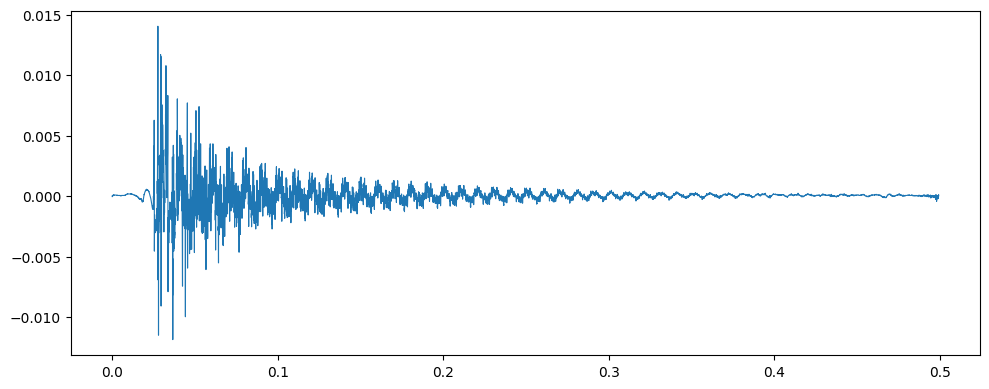

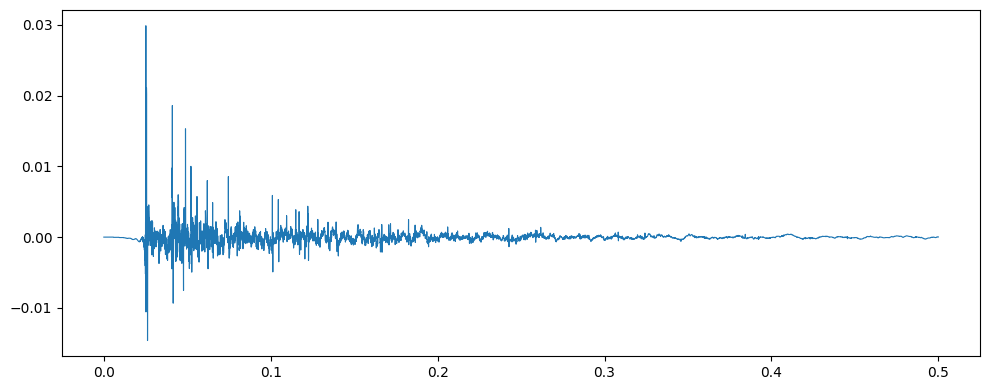

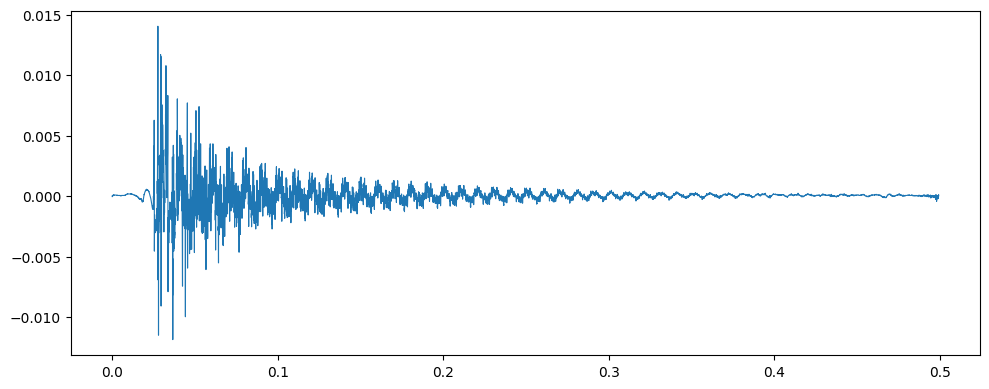

In [10]:
plot_waveform(rir, sr)
plot_waveform(pred_rir, sr)

In [5]:
frame_rate = 50
oct_energy_histogram = convert_stft_db_to_octave_db(extract_stft_energy_db(rir, sr=sr, frame_rate=frame_rate))
pred_oct_energy_histogram = convert_stft_db_to_octave_db(extract_stft_energy_db(pred_rir, sr=sr, frame_rate=frame_rate))
# pred_align_feature_path = '/data/250010171/code/EigeNet_discriminant/data/debug/toy/pred_align_feature.npy'
# pred_align_feature = torch.from_numpy(np.load(pred_align_feature_path))[-1:]
# pred_align_feature = pred_align_feature.transpose(1, 2)
#print(f"pred_align_feature: {pred_align_feature.shape}")
mse_loss = nn.L1Loss()(oct_energy_histogram[:,:,:25], pred_oct_energy_histogram[:,:,:25])
edc_loss = spectrogram_edc_loss(oct_energy_histogram[:,:,:25], pred_oct_energy_histogram[:,:,:25])
print(f"l1 损失: {mse_loss}")
print(f"EDC 损失: {edc_loss}")


l1 损失: 5.8922319412231445
EDC 损失: 3.6394054889678955


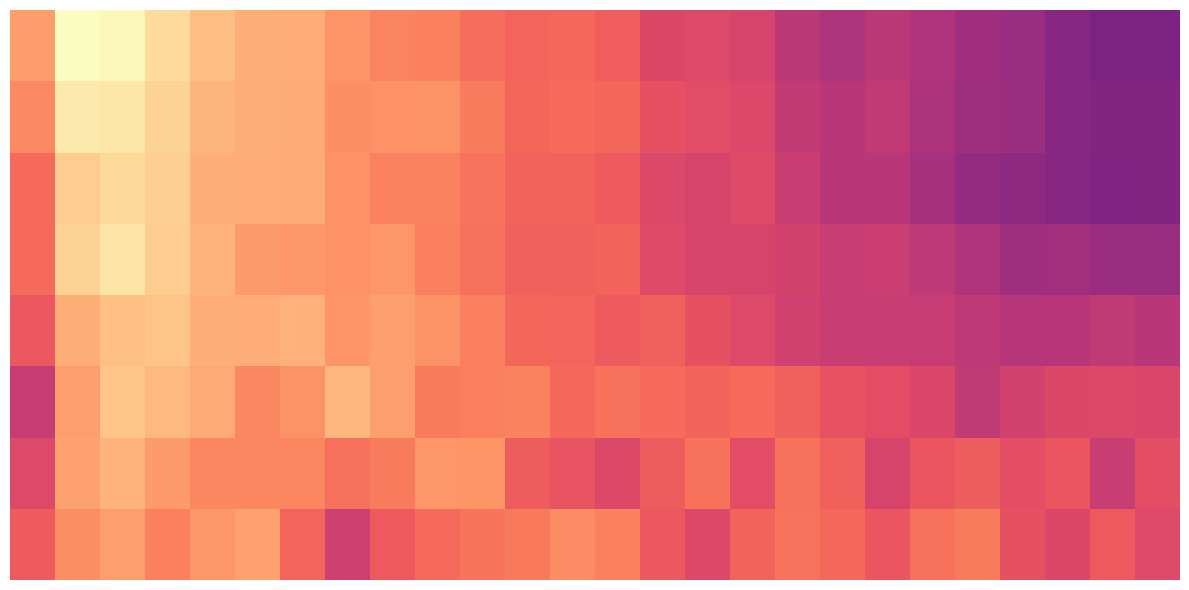

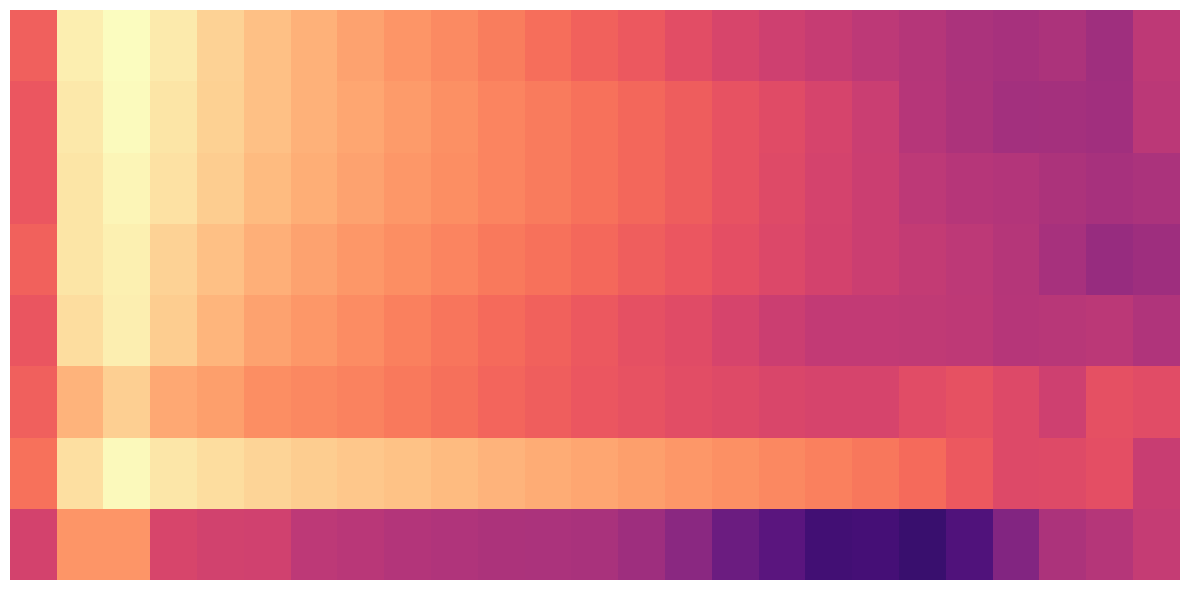

In [9]:
fig1 = plot_stft_spectrogram(oct_energy_histogram)
fig2 = plot_stft_spectrogram(pred_oct_energy_histogram)

In [10]:
fig1.savefig('/data/250010171/code/EigeNet_discriminant/data/visualization/out/spectrum.pdf')